# B3 · Transformer Attention Mechanism

Scaled dot-product attention implemented from scratch and optimised in three steps
(topic **B3** of the project catalog).

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | PyTorch on CPU | correctness reference + timing baseline |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles; (max, sum) in a single pass via log-sum-exp |
| `GpuV3` | FlashAttention-style fused kernel | tile Q, K, V together; the N×N score matrix never exists in global memory |

Following the *partial GPU principle*, everything except attention — embedding,
projections, layer norms, FFN — stays in PyTorch on the CPU. Only the profiled
bottleneck is replaced.

In [2]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

`CpuPipeline` runs the whole block in PyTorch, with every step wrapped in
`torch.profiler.record_function`. Attention is $O(N^2 D)$ compute and $O(N^2)$
memory while every other step is linear in $N$, so its share of a forward pass
grows quadratically: ~10% at $N = 128$, drawing level with the FFN around
$N = d_{ff} = 2048$ and overtaking everything beyond, as the chart confirms.
Long sequences are exactly where the bottleneck lives — which is why attention,
and only attention, is the GPU target.

In [3]:
# Correctness gate: the baseline must match torch's SDPA before it can serve as reference.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    torch.testing.assert_close(cpu_model(x), bench.sdpa_reference(cpu_model, x))
print("CpuPipeline matches torch.nn.functional.scaled_dot_product_attention")

CpuPipeline matches torch.nn.functional.scaled_dot_product_attention


/home/nvidia/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-19 18:19:35 2555405:2555405 ActivityProfilerController.cpp:455] profiler_st

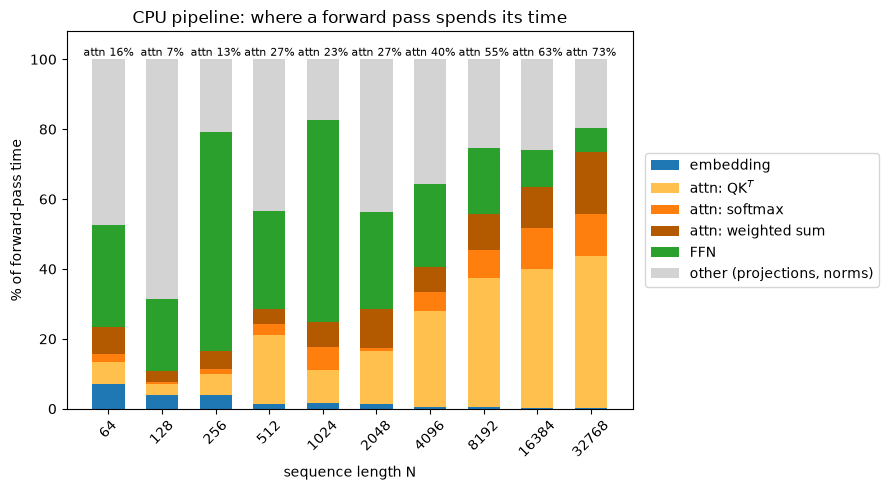

In [4]:
# Chart 1 -- share of forward-pass time per step (CPU pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 16)]
pcts = [bench.step_percentages(cpu_model, n) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("CPU pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

**V1 — naive three-kernel** (`gpu_v1.py`): `_matmul` (QK$^T$), `_scale`,
`_softmax`, `_matmul` (weights·V) — four launches, and every intermediate
including the full N×N score matrix round-trips through global memory.
The matmul loads are coalesced (adjacent threads read adjacent addresses) but
nothing is reused, and the softmax — one thread per row, three reads of the
row — is fully uncoalesced; V2's block-per-row softmax fixes both.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from global
memory 16× less often; shared arrays are padded to dodge bank conflicts) and fuses
the $1/\sqrt{D}$ scaling into the epilogue. `_softmax_online` uses one block
per row: a running (max, sum) pair rescaled when the max moves — the
log-sum-exp trick — gets both out of **one** coalesced read of the row.

**V3 — FlashAttention-style fused kernel** (`gpu_v3.py`): a single kernel,
one **warp per four query rows** (8 warps per block). K/V tiles live in
shared memory and are reused by all 32 rows of the block; the query rows and
output accumulators are split across the 32 lanes' registers, register-tiled
so that **each K/V element fetched from shared memory feeds four FMAs** — no
N×N intermediate exists anywhere. Dot products are reduced with warp shuffles
(`shfl_xor_sync` butterfly), and the softmax runs online while the weighted
sum accumulates. Extra memory drops from $O(N^2)$ to $O(N)$.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [5]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/nvidia/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/nvidia/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/nvidia/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/nvidia/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4


TypingError: Failed in cuda mode pipeline (step: nopython frontend)
No implementation of function Function(<function shared.array at 0x7d5b5139f7e0>) found for signature:
 
 >>> array(Tuple(Literal[int](16), int64), class(float32))
 
There are 2 candidate implementations:
 - Of which 2 did not match due to:
 Overload of function 'array': File: numba/cuda/cudadecl.py: Line 27.
   With argument(s): '(UniTuple(int64 x 2), class(float32))':
  No match.

During: resolving callee type: Function(<function shared.array at 0x7d5b5139f7e0>)
During: typing of call at /home/nvidia/gpt/src/gpu_v2.py (25)
During: typing of call at /home/nvidia/gpt/src/gpu_v2.py (26)

File "src/gpu_v2.py", line 25:
def _qkt_tiled(q, k, scale, out):
    <source elided>
    """
    sq = cuda.shared.array((TILE, TILE + 1), float32)
    ^

During: Pass nopython_type_inference

## Benchmark — attention step time

Timings are for the attention step only, on precomputed q, k, v — and they
*include* the CPU→GPU and GPU→CPU transfers, because that is the true cost of
swapping a kernel into an otherwise-CPU pipeline. Sequence lengths sweep the
powers of two from $2^6$ to $2^{15}$ (64 → 32768), passing through the spec's
128 / 512 / 2048 checkpoints on the way.

Keep in mind the bar: the "CPU" attention step is torch's multithreaded
MKL/BLAS matmul, not a naive loop. A naive kernel with coalesced
matmuls (V1) roughly ties it — the real wins come from data reuse (V2) and
fusion (V3).

In [ ]:
SEQ_LENS = [2 ** x for x in range(6, 16)]

if cuda.is_available():
    classes = {"CPU": CpuPipeline,
               "V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               "V3 flash fused": GpuV3}
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    times["torch SDPA (GPU)"] = [bench.sdpa_gpu_ms(cpu_model, n, reps=3) for n in SEQ_LENS]

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

In [ ]:
# Chart 2 -- attention step time vs sequence length
if cuda.is_available():
    style = {"CPU": ("black", "-"), "V1 naive": ("tab:blue", "-"),
             "V2 tiled + online softmax": ("tab:orange", "-"),
             "V3 flash fused": ("tab:green", "-"), "torch SDPA (GPU)": ("gray", "--")}

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, ts in times.items():
        color, ls = style[name]
        ax.plot(SEQ_LENS, ts, marker="o", color=color, linestyle=ls, label=name)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("attention step time (ms)")
    ax.set_title("Attention step time (incl. transfers)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Chart 3 -- speedup over the CPU attention step across the full sweep
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name, ts in times.items():
        if name == "CPU":
            continue
        color, ls = style[name]
        speedups = [c / t for c, t in zip(times["CPU"], ts)]
        ax.plot(SEQ_LENS, speedups, marker="o", color=color, linestyle=ls, label=name)

    ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("speedup over CPU attention (x)")
    ax.set_title("Attention step speedup vs CPU baseline")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()